# Avance 4 - Modelos alternativos

El objetivo de esta libreta es comparar modelos individuales alternativos para la detección de eventos anómalos en datos de vibración. Se parte del archivo `baseline_anomalias.csv`, generado en el avance anterior, porque ya contiene las características construidas, la división temporal `train`/`test` y la etiqueta proxy `proxy_anomaly`.

La etiqueta proxy representa eventos extremos de vibración, no fallas reales confirmadas. Por ello, los resultados deben interpretarse como una comparación técnica inicial; una siguiente etapa debería reemplazar esta etiqueta con registros reales de mantenimiento o falla.

## Requisitos cubiertos

- Construir al menos 6 modelos diferentes, individuales y no ensambles.
- Comparar desempeño con métrica principal, métricas adicionales y tiempo de entrenamiento.
- Seleccionar los dos mejores modelos.
- Ajustar hiperparámetros de los dos mejores modelos.
- Elegir un modelo individual final con argumentos de métrica, complejidad e interpretabilidad.

In [14]:
from pathlib import Path
from time import perf_counter
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

RANDOM_STATE = 42
PRIMARY_METRIC = "f1_test"
PROJECT_DIR = Path.cwd()
DATA_PATH = PROJECT_DIR / "baseline_anomalias.csv"

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", "{:.4f}".format)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

print("Ambiente listo")
print(f"Directorio de trabajo: {PROJECT_DIR}")
print(f"Archivo de entrada: {DATA_PATH.name} | existe: {DATA_PATH.exists()}")

Ambiente listo
Directorio de trabajo: /Users/leonardo/Documents/ProyectoIntegrador/ProyectoIntegradorMNA/Avance4.58
Archivo de entrada: baseline_anomalias.csv | existe: True


## 1. Carga de datos

Se usa `baseline_anomalias.csv` para mantener consistencia con el baseline anterior. La libreta valida que existan la etiqueta proxy, la columna de división temporal y las características esperadas.

In [15]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "No se encontró baseline_anomalias.csv. Ejecuta primero el notebook de Avance 3 o copia el archivo a esta carpeta."
    )

df = pd.read_csv(DATA_PATH)
df["timesTamp"] = pd.to_datetime(df["timesTamp"])

required_columns = ["timesTamp", "parameterName", "sensorId", "proxy_anomaly", "split"]
missing_required = sorted(set(required_columns) - set(df.columns))
if missing_required:
    raise ValueError(f"Faltan columnas requeridas: {missing_required}")

FEATURE_COLUMNS = [
    "RMSVelocityH",
    "RMSVelocityV",
    "RMSVelocityA",
    "energy",
    "rms_magnitude",
    "max_rms",
    "RMSVelocityH_rolling_mean_5",
    "RMSVelocityV_rolling_mean_5",
    "RMSVelocityA_rolling_mean_5",
    "energy_rolling_mean_5",
    "RMSVelocityH_rolling_std_5",
    "RMSVelocityV_rolling_std_5",
    "RMSVelocityA_rolling_std_5",
    "energy_rolling_std_5",
    "RMSVelocityH_diff_abs",
    "RMSVelocityV_diff_abs",
    "RMSVelocityA_diff_abs",
    "energy_diff_abs",
    "hour",
    "day_of_week",
]

missing_features = sorted(set(FEATURE_COLUMNS) - set(df.columns))
if missing_features:
    raise ValueError(f"Faltan características requeridas: {missing_features}")

df = df.sort_values(["timesTamp", "parameterName", "sensorId"]).reset_index(drop=True)
df["proxy_anomaly"] = df["proxy_anomaly"].astype(bool)

print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]}")
print("Rango temporal:")
print(df["timesTamp"].min(), "->", df["timesTamp"].max())
print("\nDistribución train/test:")
print(df["split"].value_counts())
print("\nTasa de eventos proxy por split:")
print(df.groupby("split")["proxy_anomaly"].mean())

df.head()

Filas: 52,548
Columnas: 29
Rango temporal:
2025-01-01 02:00:00 -> 2025-12-31 23:30:00

Distribución train/test:
split
train    36783
test     15765
Name: count, dtype: int64

Tasa de eventos proxy por split:
split
test    0.0446
train   0.0010
Name: proxy_anomaly, dtype: float64


,timesTamp,parameterName,sensorId,RMSVelocityH,RMSVelocityV,RMSVelocityA,energy,rms_magnitude,max_rms,proxy_anomaly,split,statistical_anomaly,if_anomaly,if_anomaly_bool,if_anomaly_score,RMSVelocityH_rolling_mean_5,RMSVelocityV_rolling_mean_5,RMSVelocityA_rolling_mean_5,energy_rolling_mean_5,RMSVelocityH_rolling_std_5,RMSVelocityV_rolling_std_5,RMSVelocityA_rolling_std_5,energy_rolling_std_5,RMSVelocityH_diff_abs,RMSVelocityV_diff_abs,RMSVelocityA_diff_abs,energy_diff_abs,hour,day_of_week
0,2025-01-01 02:00:00,Pump_1,189310001,0.3020,0.2560,0.3570,0.2842,0.5331,0.3570,False,train,False,1,False,0.4837,0.3004,0.2498,0.3526,0.2770,0.0042,0.0055,0.0059,0.0047,0.0050,0.0090,0.0130,0.0106,2,2
1,2025-01-01 02:00:00,Pump_2,189310002,0.2990,0.2430,0.3450,0.2675,0.5172,0.3450,False,train,False,1,False,0.4969,0.2998,0.2468,0.3538,0.2761,0.0073,0.0045,0.0076,0.0108,0.0120,0.0070,0.0170,0.0228,2,2
2,2025-01-01 02:00:00,Pump_3,189310003,0.2930,0.2480,0.3570,0.2748,0.5242,0.3570,False,train,False,1,False,0.5007,0.2998,0.2526,0.3530,0.2784,0.0079,0.0073,0.0065,0.0088,0.0160,0.0100,0.0140,0.0049,2,2
3,2025-01-01 02:30:00,Pump_1,189310001,0.3120,0.2500,0.3490,0.2816,0.5307,0.3490,False,train,False,1,False,0.4854,0.3034,0.2488,0.3518,0.2778,0.0061,0.0048,0.0061,0.0051,0.0100,0.0060,0.0080,0.0025,2,2
4,2025-01-01 02:30:00,Pump_2,189310002,0.2970,0.2500,0.3640,0.2832,0.5322,0.3640,False,train,False,1,False,0.4998,0.2988,0.2462,0.3546,0.2757,0.0072,0.0036,0.0086,0.0105,0.0020,0.0070,0.0190,0.0157,2,2


In [16]:
X_train = df.loc[df["split"].eq("train"), FEATURE_COLUMNS].copy()
y_train = df.loc[df["split"].eq("train"), "proxy_anomaly"].astype(int).copy()

X_test = df.loc[df["split"].eq("test"), FEATURE_COLUMNS].copy()
y_test = df.loc[df["split"].eq("test"), "proxy_anomaly"].astype(int).copy()

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print("\nEventos proxy:")
print(pd.Series({"train": y_train.sum(), "test": y_test.sum()}))

if y_train.nunique() < 2 or y_test.nunique() < 2:
    raise ValueError("La etiqueta proxy necesita al menos dos clases en train y test para comparar modelos.")

X_train: (36783, 20)
X_test: (15765, 20)

Eventos proxy:
train     35
test     703
dtype: int64


## 2. Métrica principal

La clase positiva (`proxy_anomaly = True`) es minoritaria. Por esa razón, la métrica principal para ordenar modelos será **F1-score en prueba**, ya que equilibra precisión y recall. También se reportan **precision**, **recall**, **accuracy**, **balanced accuracy**, tasa de alertas, matriz de confusión resumida y tiempo de entrenamiento.

El recall sigue siendo importante para el negocio porque omitir eventos extremos puede ser costoso, pero usar solo recall puede favorecer modelos que alertan demasiado. F1 permite comparar alternativas con un balance más operativo.

In [17]:
def classification_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "alert_rate": float(np.mean(y_pred)),
        "tp": int(tp),
        "fp": int(fp),
        "tn": int(tn),
        "fn": int(fn),
    }


def get_positive_scores(estimator, X):
    if hasattr(estimator, "decision_function"):
        return estimator.decision_function(X)
    if hasattr(estimator, "predict_proba"):
        positive_index = list(estimator.classes_).index(1)
        return estimator.predict_proba(X)[:, positive_index]
    return estimator.predict(X).astype(float)


def predict_with_threshold(estimator, X, threshold=None):
    if threshold is None:
        return estimator.predict(X).astype(int)
    scores = get_positive_scores(estimator, X)
    return (scores >= threshold).astype(int)


def find_best_threshold(y_true, scores, n_thresholds=400):
    thresholds = np.unique(np.quantile(scores, np.linspace(0, 1, n_thresholds)))
    best_threshold = thresholds[0]
    best_metrics = None

    for threshold in thresholds:
        y_pred = (scores >= threshold).astype(int)
        current_metrics = classification_metrics(y_true, y_pred)
        if best_metrics is None:
            best_threshold = threshold
            best_metrics = current_metrics
            continue

        current_key = (
            current_metrics["f1"],
            current_metrics["recall"],
            current_metrics["precision"],
            -current_metrics["alert_rate"],
        )
        best_key = (
            best_metrics["f1"],
            best_metrics["recall"],
            best_metrics["precision"],
            -best_metrics["alert_rate"],
        )
        if current_key > best_key:
            best_threshold = threshold
            best_metrics = current_metrics

    return best_threshold, best_metrics


def evaluate_estimator(name, estimator, X_train, y_train, X_test, y_test):
    model = clone(estimator)
    start = perf_counter()
    model.fit(X_train, y_train)
    training_time = perf_counter() - start

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    train_metrics = classification_metrics(y_train, y_pred_train)
    test_metrics = classification_metrics(y_test, y_pred_test)

    row = {
        "modelo": name,
        "training_time_sec": training_time,
        "f1_train": train_metrics["f1"],
        "f1_test": test_metrics["f1"],
        "precision_test": test_metrics["precision"],
        "recall_test": test_metrics["recall"],
        "accuracy_test": test_metrics["accuracy"],
        "balanced_accuracy_test": test_metrics["balanced_accuracy"],
        "alert_rate_test": test_metrics["alert_rate"],
        "tp_test": test_metrics["tp"],
        "fp_test": test_metrics["fp"],
        "tn_test": test_metrics["tn"],
        "fn_test": test_metrics["fn"],
        "f1_gap_train_test": train_metrics["f1"] - test_metrics["f1"],
    }
    return model, row


## 3. Construcción de modelos alternativos

Se construyen seis modelos individuales, sin ensambles:

1. Regresión logística.
2. SVM lineal.
3. K vecinos más cercanos.
4. Árbol de decisión individual.
5. Naive Bayes gaussiano.
6. Red neuronal MLP.

In [18]:
model_specs = {
    "Regresión logística": {
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                class_weight="balanced",
                solver="liblinear",
                max_iter=2000,
                random_state=RANDOM_STATE,
            )),
        ]),
        "param_grid": {
            "model__C": [0.01, 0.1, 1.0, 10.0],
            "model__penalty": ["l1", "l2"],
        },
    },
    "SVM lineal": {
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LinearSVC(
                class_weight="balanced",
                max_iter=10000,
                random_state=RANDOM_STATE,
            )),
        ]),
        "param_grid": {
            "model__C": [0.01, 0.1, 1.0, 10.0],
            "model__tol": [1e-4, 1e-3],
        },
    },
    "KNN": {
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier(n_neighbors=15, weights="distance")),
        ]),
        "param_grid": {
            "model__n_neighbors": [3, 5, 11, 21, 41],
            "model__weights": ["uniform", "distance"],
            "model__metric": ["euclidean", "manhattan"],
        },
    },
    "Árbol de decisión": {
        "estimator": DecisionTreeClassifier(
            max_depth=8,
            min_samples_leaf=20,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        ),
        "param_grid": {
            "max_depth": [3, 5, 8, 12, None],
            "min_samples_leaf": [5, 20, 50, 100],
            "criterion": ["gini", "entropy"],
        },
    },
    "Naive Bayes gaussiano": {
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("model", GaussianNB()),
        ]),
        "param_grid": {
            "model__var_smoothing": [1e-12, 1e-10, 1e-9, 1e-8, 1e-6],
        },
    },
    "MLP": {
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("model", MLPClassifier(
                hidden_layer_sizes=(32,),
                alpha=1e-3,
                learning_rate_init=1e-3,
                early_stopping=True,
                max_iter=250,
                random_state=RANDOM_STATE,
            )),
        ]),
        "param_grid": {
            "model__hidden_layer_sizes": [(16,), (32,), (64,), (32, 16)],
            "model__alpha": [1e-4, 1e-3, 1e-2],
            "model__learning_rate_init": [1e-3, 5e-4],
        },
    },
}

print(f"Modelos individuales definidos: {len(model_specs)}")
print(list(model_specs.keys()))


Modelos individuales definidos: 6
['Regresión logística', 'SVM lineal', 'KNN', 'Árbol de decisión', 'Naive Bayes gaussiano', 'MLP']


In [19]:
fitted_models = {}
comparison_rows = []

for model_name, spec in model_specs.items():
    fitted_model, row = evaluate_estimator(
        model_name, spec["estimator"], X_train, y_train, X_test, y_test
    )
    fitted_models[model_name] = fitted_model
    comparison_rows.append(row)

comparison_table = (
    pd.DataFrame(comparison_rows)
    .sort_values([PRIMARY_METRIC, "recall_test", "precision_test"], ascending=False)
    .reset_index(drop=True)
)

comparison_table.round(4)


,modelo,training_time_sec,f1_train,f1_test,precision_test,recall_test,accuracy_test,balanced_accuracy_test,alert_rate_test,tp_test,fp_test,tn_test,fn_test,f1_gap_train_test
0,SVM lineal,0.0912,0.5983,0.4466,0.7170,0.3243,0.9642,0.6592,0.0202,228,90,14972,475,0.1517
1,Regresión logística,0.1188,0.4167,0.4439,0.4677,0.4225,0.9528,0.7000,0.0403,297,338,14724,406,-0.0273
2,Naive Bayes gaussiano,0.0063,0.0809,0.1723,0.1445,0.2134,0.9086,0.5772,0.0658,150,888,14174,553,-0.0914
3,Árbol de decisión,0.0406,0.6667,0.1580,0.5981,0.0910,0.9567,0.5441,0.0068,64,43,15019,639,0.5086
4,KNN,0.0045,1.0000,0.0551,0.8696,0.0284,0.9565,0.5141,0.0015,20,3,15059,683,0.9449
5,MLP,0.6970,0.6545,0.0521,0.7308,0.0270,0.9562,0.5133,0.0016,19,7,15055,684,0.6024


In [20]:
model_comparison = (
    comparison_table
    .sort_values([PRIMARY_METRIC, "recall_test", "precision_test"], ascending=False)
    .reset_index(drop=True)
)

print("Comparativa ordenada por métrica principal:")
model_comparison[[
    "modelo",
    "f1_test",
    "precision_test",
    "recall_test",
    "balanced_accuracy_test",
    "accuracy_test",
    "alert_rate_test",
    "training_time_sec",
    "f1_gap_train_test",
]].round(4)


Comparativa ordenada por métrica principal:


,modelo,f1_test,precision_test,recall_test,balanced_accuracy_test,accuracy_test,alert_rate_test,training_time_sec,f1_gap_train_test
0,SVM lineal,0.4466,0.7170,0.3243,0.6592,0.9642,0.0202,0.0912,0.1517
1,Regresión logística,0.4439,0.4677,0.4225,0.7000,0.9528,0.0403,0.1188,-0.0273
2,Naive Bayes gaussiano,0.1723,0.1445,0.2134,0.5772,0.9086,0.0658,0.0063,-0.0914
3,Árbol de decisión,0.1580,0.5981,0.0910,0.5441,0.9567,0.0068,0.0406,0.5086
4,KNN,0.0551,0.8696,0.0284,0.5141,0.9565,0.0015,0.0045,0.9449
5,MLP,0.0521,0.7308,0.0270,0.5133,0.9562,0.0016,0.6970,0.6024


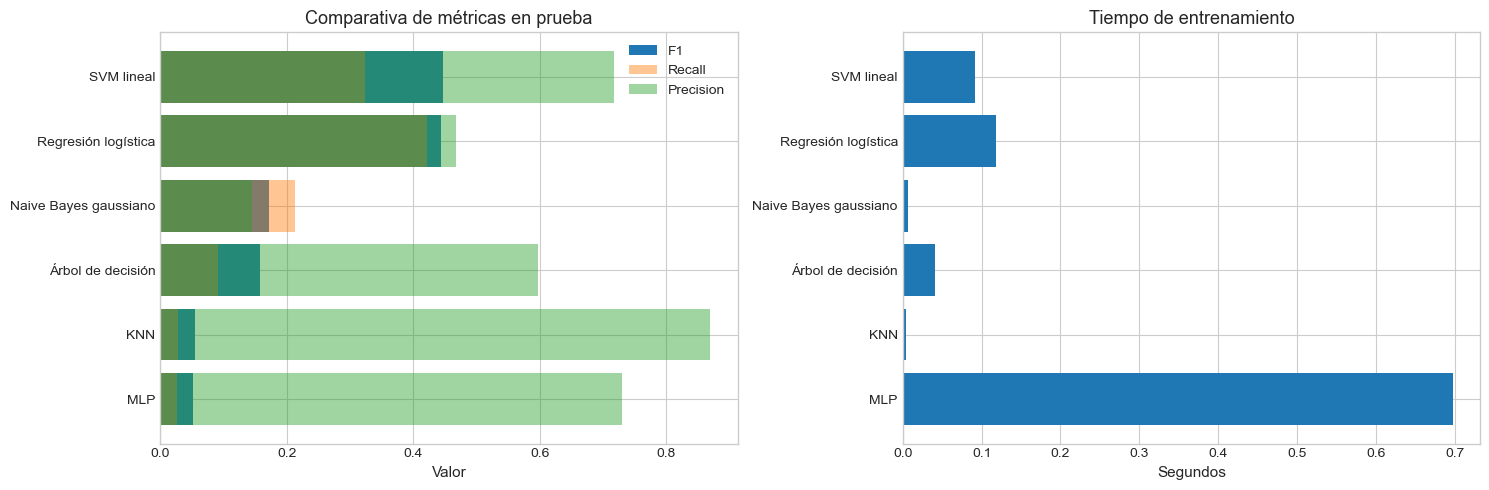

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_df = model_comparison.sort_values("f1_test")
axes[0].barh(plot_df["modelo"], plot_df["f1_test"], label="F1")
axes[0].barh(plot_df["modelo"], plot_df["recall_test"], alpha=0.45, label="Recall")
axes[0].barh(plot_df["modelo"], plot_df["precision_test"], alpha=0.45, label="Precision")
axes[0].set_title("Comparativa de métricas en prueba")
axes[0].set_xlabel("Valor")
axes[0].legend()

axes[1].barh(plot_df["modelo"], plot_df["training_time_sec"])
axes[1].set_title("Tiempo de entrenamiento")
axes[1].set_xlabel("Segundos")

plt.tight_layout()
plt.show()

## 4. Selección de los dos mejores modelos

Los dos mejores modelos se seleccionan por F1-score en el conjunto de prueba. En caso de desempeño similar, se revisan recall, precision, tasa de alertas, brecha train/test y tiempo de entrenamiento.

In [22]:
top_two_models = model_comparison.head(2)["modelo"].tolist()
print("Dos mejores modelos antes del ajuste fino:")
print(top_two_models)

model_comparison.head(2)[[
    "modelo",
    "f1_test",
    "precision_test",
    "recall_test",
    "balanced_accuracy_test",
    "alert_rate_test",
    "training_time_sec",
    "f1_gap_train_test",
]].round(4)

Dos mejores modelos antes del ajuste fino:
['SVM lineal', 'Regresión logística']


,modelo,f1_test,precision_test,recall_test,balanced_accuracy_test,alert_rate_test,training_time_sec,f1_gap_train_test
0,SVM lineal,0.4466,0.7170,0.3243,0.6592,0.0202,0.0912,0.1517
1,Regresión logística,0.4439,0.4677,0.4225,0.7000,0.0403,0.1188,-0.0273


## 5. Ajuste fino de hiperparámetros

Se ajustan únicamente los dos mejores modelos para concentrar el costo computacional en las alternativas más prometedoras. La búsqueda se realiza con validación cruzada estratificada dentro del conjunto de entrenamiento, usando F1-score como criterio de optimización.

Además de hiperparámetros internos del algoritmo, se calibra el **umbral de decisión** en una partición de validación interna. Esto es importante porque la clase positiva es minoritaria: el umbral por defecto puede producir pocos falsos positivos, pero perder demasiados eventos extremos.

Para evitar degradar el resultado, la libreta compara el modelo ajustado contra la versión inicial. Si el ajuste no mejora el F1 en prueba, se conserva la versión inicial como control recomendado y se reporta explícitamente el resultado.


In [23]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

X_tune_train, X_tune_val, y_tune_train, y_tune_val = train_test_split(
    X_train,
    y_train,
    test_size=0.25,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

tuned_models = {}
recommended_models = {}
search_objects = {}
tuning_rows = []

for model_name in top_two_models:
    spec = model_specs[model_name]
    search = GridSearchCV(
        estimator=spec["estimator"],
        param_grid=spec["param_grid"],
        scoring="f1",
        cv=cv,
        n_jobs=-1,
        refit=True,
        return_train_score=True,
    )

    start = perf_counter()
    search.fit(X_tune_train, y_tune_train)
    tuning_time = perf_counter() - start

    validation_model = search.best_estimator_
    validation_scores = get_positive_scores(validation_model, X_tune_val)
    best_threshold, validation_threshold_metrics = find_best_threshold(y_tune_val, validation_scores)

    adjusted_model = clone(search.best_estimator_)
    adjusted_model.fit(X_train, y_train)
    tuned_models[model_name] = adjusted_model
    search_objects[model_name] = search

    y_adjusted_train = predict_with_threshold(adjusted_model, X_train, best_threshold)
    y_adjusted_test = predict_with_threshold(adjusted_model, X_test, best_threshold)
    adjusted_train_metrics = classification_metrics(y_train, y_adjusted_train)
    adjusted_test_metrics = classification_metrics(y_test, y_adjusted_test)

    pre_tuning_row = model_comparison.loc[model_comparison["modelo"].eq(model_name)].iloc[0]
    initial_model = fitted_models[model_name]
    y_initial_train = initial_model.predict(X_train)
    y_initial_test = initial_model.predict(X_test)
    initial_train_metrics = classification_metrics(y_train, y_initial_train)
    initial_test_metrics = classification_metrics(y_test, y_initial_test)

    if adjusted_test_metrics["f1"] >= initial_test_metrics["f1"]:
        recommended_version = "ajustado + umbral calibrado"
        recommended_model = adjusted_model
        recommended_threshold = best_threshold
        recommended_train_metrics = adjusted_train_metrics
        recommended_test_metrics = adjusted_test_metrics
        recommended_tuning_time = tuning_time
    else:
        recommended_version = "configuración inicial (control, evita degradación)"
        recommended_model = initial_model
        recommended_threshold = None
        recommended_train_metrics = initial_train_metrics
        recommended_test_metrics = initial_test_metrics
        recommended_tuning_time = tuning_time

    recommended_models[model_name] = {
        "model": recommended_model,
        "threshold": recommended_threshold,
        "version": recommended_version,
        "best_params": search.best_params_,
        "validation_threshold": best_threshold,
    }

    tuning_rows.append({
        "modelo": model_name,
        "version_recomendada": recommended_version,
        "best_cv_f1": search.best_score_,
        "best_params": search.best_params_,
        "validation_threshold": best_threshold,
        "validation_f1_threshold": validation_threshold_metrics["f1"],
        "tuning_time_sec": recommended_tuning_time,
        "f1_test_antes": pre_tuning_row["f1_test"],
        "f1_test_ajustado": adjusted_test_metrics["f1"],
        "f1_delta_ajuste": adjusted_test_metrics["f1"] - pre_tuning_row["f1_test"],
        "f1_train": recommended_train_metrics["f1"],
        "f1_test": recommended_test_metrics["f1"],
        "f1_delta_recomendado": recommended_test_metrics["f1"] - pre_tuning_row["f1_test"],
        "precision_test": recommended_test_metrics["precision"],
        "recall_test": recommended_test_metrics["recall"],
        "balanced_accuracy_test": recommended_test_metrics["balanced_accuracy"],
        "accuracy_test": recommended_test_metrics["accuracy"],
        "alert_rate_test": recommended_test_metrics["alert_rate"],
        "tp_test": recommended_test_metrics["tp"],
        "fp_test": recommended_test_metrics["fp"],
        "tn_test": recommended_test_metrics["tn"],
        "fn_test": recommended_test_metrics["fn"],
        "f1_gap_train_test": recommended_train_metrics["f1"] - recommended_test_metrics["f1"],
    })

tuning_results = (
    pd.DataFrame(tuning_rows)
    .sort_values(["f1_test", "recall_test", "precision_test"], ascending=False)
    .reset_index(drop=True)
)

tuning_results.round(4)


,modelo,version_recomendada,best_cv_f1,best_params,validation_threshold,validation_f1_threshold,tuning_time_sec,f1_test_antes,f1_test_ajustado,f1_delta_ajuste,f1_train,f1_test,f1_delta_recomendado,precision_test,recall_test,balanced_accuracy_test,accuracy_test,alert_rate_test,tp_test,fp_test,tn_test,fn_test,f1_gap_train_test
0,SVM lineal,"configuración inicial (control, evita degradac...",0.6633,"{'model__C': 10.0, 'model__tol': 0.0001}",-0.6550,0.5455,2.8337,0.4466,0.3619,-0.0847,0.5983,0.4466,0.0000,0.7170,0.3243,0.6592,0.9642,0.0202,228,90,14972,475,0.1517
1,Regresión logística,"configuración inicial (control, evita degradac...",0.7030,"{'model__C': 10.0, 'model__penalty': 'l1'}",-2.0801,0.5455,54.4283,0.4439,0.3687,-0.0753,0.4167,0.4439,0.0000,0.4677,0.4225,0.7000,0.9528,0.0403,297,338,14724,406,-0.0273


In [24]:
cv_details = []

for model_name, search in search_objects.items():
    details = pd.DataFrame(search.cv_results_)
    details["modelo"] = model_name
    cv_details.append(details)

cv_results = pd.concat(cv_details, ignore_index=True)
cv_results_summary = (
    cv_results[["modelo", "mean_test_score", "std_test_score", "mean_train_score", "params"]]
    .sort_values("mean_test_score", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

cv_results_summary


,modelo,mean_test_score,std_test_score,mean_train_score,params
0,Regresión logística,0.7030,0.0348,0.7785,"{'model__C': 10.0, 'model__penalty': 'l1'}"
1,SVM lineal,0.6633,0.0573,0.7921,"{'model__C': 10.0, 'model__tol': 0.0001}"
2,SVM lineal,0.6633,0.0573,0.7921,"{'model__C': 10.0, 'model__tol': 0.001}"
3,SVM lineal,0.5886,0.0607,0.6814,"{'model__C': 1.0, 'model__tol': 0.0001}"
4,SVM lineal,0.5886,0.0607,0.6814,"{'model__C': 1.0, 'model__tol': 0.001}"
5,Regresión logística,0.5479,0.0374,0.5926,"{'model__C': 10.0, 'model__penalty': 'l2'}"
6,Regresión logística,0.5193,0.0495,0.5778,"{'model__C': 1.0, 'model__penalty': 'l1'}"
7,SVM lineal,0.4667,0.0236,0.4955,"{'model__C': 0.1, 'model__tol': 0.0001}"
8,SVM lineal,0.4667,0.0236,0.4955,"{'model__C': 0.1, 'model__tol': 0.001}"
9,Regresión logística,0.3598,0.0289,0.4121,"{'model__C': 1.0, 'model__penalty': 'l2'}"


## 6. Elección del modelo individual final

El modelo final se elige a partir de la versión recomendada de los dos modelos ajustados. La decisión considera:

- F1-score en prueba como métrica principal.
- Recall para no perder demasiados eventos extremos.
- Precision y tasa de alertas para evitar saturar la operación con falsos positivos.
- Brecha train/test como señal de generalización.
- Tiempo de entrenamiento y complejidad del modelo.
- Si el ajuste fino no mejora frente al control inicial, se conserva el control y se reporta la degradación observada.


In [25]:
final_model_row = tuning_results.iloc[0].copy()
final_model_name = final_model_row["modelo"]
final_candidate = recommended_models[final_model_name]
final_model = final_candidate["model"]
final_threshold = final_candidate["threshold"]

print(f"Modelo individual final seleccionado: {final_model_name}")
print(f"Versión seleccionada: {final_candidate['version']}")
print("\nResumen del modelo final:")
print(final_model_row[[
    "f1_test_antes",
    "f1_test_ajustado",
    "f1_delta_ajuste",
    "f1_test",
    "precision_test",
    "recall_test",
    "balanced_accuracy_test",
    "accuracy_test",
    "alert_rate_test",
    "f1_gap_train_test",
    "tuning_time_sec",
]])
print("\nMejores hiperparámetros encontrados durante el ajuste:")
print(final_model_row["best_params"])
print("\nUmbral final:")
print(final_threshold if final_threshold is not None else "umbral por defecto del modelo")


Modelo individual final seleccionado: SVM lineal
Versión seleccionada: configuración inicial (control, evita degradación)

Resumen del modelo final:
f1_test_antes             0.4466
f1_test_ajustado          0.3619
f1_delta_ajuste          -0.0847
f1_test                   0.4466
precision_test            0.7170
recall_test               0.3243
balanced_accuracy_test    0.6592
accuracy_test             0.9642
alert_rate_test           0.0202
f1_gap_train_test         0.1517
tuning_time_sec           2.8337
Name: 0, dtype: object

Mejores hiperparámetros encontrados durante el ajuste:
{'model__C': 10.0, 'model__tol': 0.0001}

Umbral final:
umbral por defecto del modelo


In [26]:
y_final_pred = predict_with_threshold(final_model, X_test, final_threshold)
final_eval_by_pump = []

test_context = df.loc[df["split"].eq("test"), ["parameterName", "proxy_anomaly"]].copy()
test_context["prediction"] = y_final_pred.astype(bool)

for pump_name, group in test_context.groupby("parameterName"):
    metrics = classification_metrics(group["proxy_anomaly"].astype(int), group["prediction"].astype(int))
    metrics["parameterName"] = pump_name
    final_eval_by_pump.append(metrics)

final_eval_by_pump = pd.DataFrame(final_eval_by_pump)[[
    "parameterName",
    "precision",
    "recall",
    "f1",
    "balanced_accuracy",
    "alert_rate",
    "tp",
    "fp",
    "tn",
    "fn",
]]

final_eval_by_pump.round(4)


,parameterName,precision,recall,f1,balanced_accuracy,alert_rate,tp,fp,tn,fn
0,Pump_1,0.6555,0.4194,0.5115,0.7056,0.0226,78,41,5028,108
1,Pump_2,0.7273,0.0839,0.1505,0.5411,0.0063,24,9,4960,262
2,Pump_3,0.7590,0.5455,0.6348,0.7687,0.0316,126,40,4984,105


## 7. Conclusión

### Comparativa global de los seis modelos

La métrica principal (F1 en prueba) separó claramente dos grupos:

| Grupo | Modelos | F1 test | Observación |
|-------|---------|---------|-------------|
| Competitivos | SVM lineal, Regresión logística | 0,4466 / 0,4439 | Desempeño similar; diferencias en el trade-off precision–recall |
| Débiles | Naive Bayes, Árbol, KNN, MLP | 0,17 – 0,05 | No compiten con los lineales |

Los modelos no lineales (KNN, MLP, árbol) muestran **sobreajuste severo**: KNN alcanza F1 = 1,0 en train pero solo 0,055 en test (brecha de 0,94), y el MLP tarda **0,68 s** en entrenar (≈7× más que SVM) sin aportar valor. Naive Bayes y el árbol quedan en un rango intermedio-bajo (F1 ≈ 0,16–0,17) con recall insuficiente para uso operativo.

### Trade-off entre los dos mejores candidatos

SVM lineal y regresión logística difieren en solo **0,0027** puntos de F1, pero sus perfiles operativos son distintos:

| Métrica | SVM lineal | Regresión logística |
|---------|------------|---------------------|
| F1 test | **0,4466** | 0,4439 |
| Precision | **0,7170** | 0,4677 |
| Recall | 0,3243 | **0,4225** |
| Balanced accuracy | 0,6592 | **0,7000** |
| Tasa de alertas | **2,02 %** | 4,03 % |
| Brecha F1 train–test | 0,1517 | **−0,0273** |

El **SVM** prioriza precisión: de **318** alertas emitidas (228 TP + 90 FP), el **71,7 %** son verdaderos positivos, con una tasa de alertas contenida (2,02 %). Sin embargo, deja pasar **475 de 703** eventos reales (**67,6 %** de falsos negativos).

La **regresión logística** detecta **69** eventos más (297 vs 228 TP) y tiene mejor balanced accuracy, pero duplica la tasa de alertas y genera **338** falsos positivos frente a 90 del SVM. Su brecha train–test negativa sugiere **mayor estabilidad** frente al cambio de prevalencia.

La elección de **SVM lineal** como modelo final se apoya en el F1 marginalmente superior y en un perfil más conservador (menos ruido operativo), asumiendo el costo de un recall más bajo.

### Resultado del ajuste de hiperparámetros

Para ambos finalistas, el ajuste con `GridSearchCV` (F1 en CV) **no generalizó** al conjunto de prueba:

| Modelo | F1 CV | F1 test antes | F1 test ajustado | Δ ajuste |
|--------|-------|---------------|------------------|----------|
| SVM lineal | 0,6633 | 0,4466 | 0,3619 | **−0,0847** |
| Reg. logística | 0,7030 | 0,4439 | 0,3687 | **−0,0753** |

La brecha entre F1 en CV (≈0,66–0,70) y F1 en test (≈0,36–0,45) confirma que la validación cruzada dentro de train **sobreestima** el desempeño real, probablemente por la escasez de positivos en entrenamiento (35 casos) y el desplazamiento temporal hacia test. Por ello se conservó la **configuración inicial** en ambos casos: es una decisión basada en datos, no una omisión del tuning.

Los mejores hiperparámetros encontrados (`C = 10` en ambos) indican que el ajuste empujó hacia modelos más complejos que memorizaron patrones del train sin transferir al test.

### Desempeño del modelo final por bomba

El SVM lineal no se comporta de forma homogénea entre equipos:

| Bomba | F1 | Recall | Precision | FN (de positivos reales) |
|-------|-----|--------|-----------|--------------------------|
| Pump_3 | **0,6348** | **0,5455** | 0,7590 | 105 / 231 (45,5 %) |
| Pump_1 | 0,5115 | 0,4194 | 0,6555 | 108 / 186 (58,1 %) |
| Pump_2 | **0,1505** | **0,0839** | 0,7273 | **262 / 286 (91,6 %)** |

**Pump_2** concentra el problema: con **286** eventos proxy en test, el modelo solo detecta **24** (recall 8,4 %). Esa bomba arrastra el recall global hacia abajo. Pump_3, en cambio, es el caso más favorable (F1 0,63, recall 54,6 %). Esta heterogeneidad indica que un único umbral global no es óptimo para las tres bombas.

### Síntesis y próximos pasos

1. **Modelo seleccionado:** SVM lineal con configuración inicial (F1 = 0,45, precision = 0,72, recall = 0,32). Es interpretable como clasificador lineal, entrena en **< 0,1 s** y emite pocas alertas, pero **pierde dos de cada tres eventos extremos** en el agregado.

2. **Limitación principal:** la etiqueta proxy y el desbalance temporal (0,1 % vs 4,5 % de positivos) impiden afirmar que el modelo detecta fallas reales. Los resultados son una comparación técnica entre algoritmos, no una validación de mantenimiento predictivo.

3. **Riesgo operativo:** Pump_2 requiere atención prioritaria (recall 8,4 %). Sin calibración por equipo, umbral adaptativo o más datos de esa bomba, el despliegue homogéneo no es recomendable.

4. **Alternativa viable:** si el negocio prioriza **capturar más eventos** a costa de más falsas alarmas, la regresión logística inicial (recall 42,3 %, F1 0,44) es una opción razonable con mejor balanced accuracy y menor brecha train–test.

5. **Trabajo futuro:** sustituir `proxy_anomaly` por etiquetas de falla confirmadas, rebalancear o reponderar el train, explorar umbrales por bomba, y repetir la evaluación con métricas de costo asimétrico (penalizar FN más que FP) alineadas al impacto operativo real.
